In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import xesmf as xe                     # package for regridding 
#import cartopy.crs as ccrs              # for the regridding test(now only to understand how it works later maybe more - probably I can do a lot with this package

#import gravity toolkit 
import gravity_toolkit as gravtk

#from scipy import signal              #not sure if I need those
#import importlib

import Kyrafunctions as ky

import sys
sys.path.append('../code')


import SeaLevelContrib as slc

In [2]:
data_path = '../data/GravIs/'
output_path = '../outputs/Antarcticatest'

In [3]:
#Open the COST-G and GFZ dataset to compare 
ant = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_AIS_GRID_TUD_0003.nc")
gre= xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_GIS_GRID_TUD_0003.nc")

In [4]:

# -----------------------------
ant_y_no_interp = ky.yearlygrace(ant)
gre_y_no_interp = ky.yearlygrace(gre)

# -----------------------------
# 2. Yearly data WITH linear interpolation
# -----------------------------
ant_interp = ant.resample(time="M").interpolate("linear")
ant_y_interp = ky.yearlygrace(ant_interp)

gre_interp = gre.resample(time="M").interpolate("linear")
gre_y_interp = ky.yearlygrace(gre_interp)

# -----------------------------
# 3. Difference between them
# -----------------------------
# Difference in the dm variable
diff = ant_y_interp["dm"] - ant_y_no_interp["dm"]

# Summary statistics
print("\n=== Difference summary ===")
print("Mean difference:", float(diff.mean().values))
print("Max difference :", float(diff.max().values))
print("Min difference :", float(diff.min().values))
print("Std difference :", float(diff.std().values))

# Optional: absolute difference
abs_diff = abs(diff)
print("\n=== Absolute difference summary ===")
print("Mean absolute diff:", float(abs_diff.mean().values))
print("Max absolute diff :", float(abs_diff.max().values))



=== Difference summary ===
Mean difference: 0.6174682388441857
Max difference : 519.9422228508888
Min difference : -396.3755143031967
Std difference : 21.840035778509243

=== Absolute difference summary ===
Mean absolute diff: 8.279260077552259
Max absolute diff : 519.9422228508888


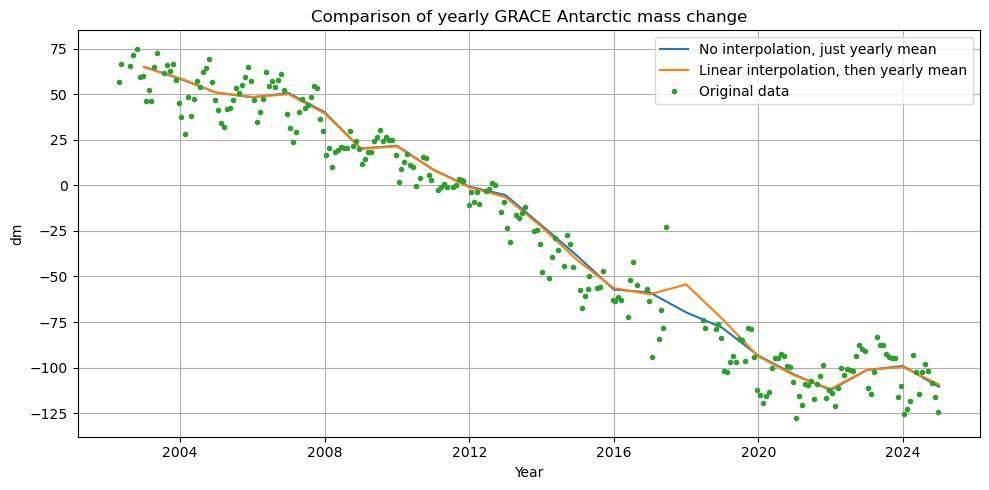

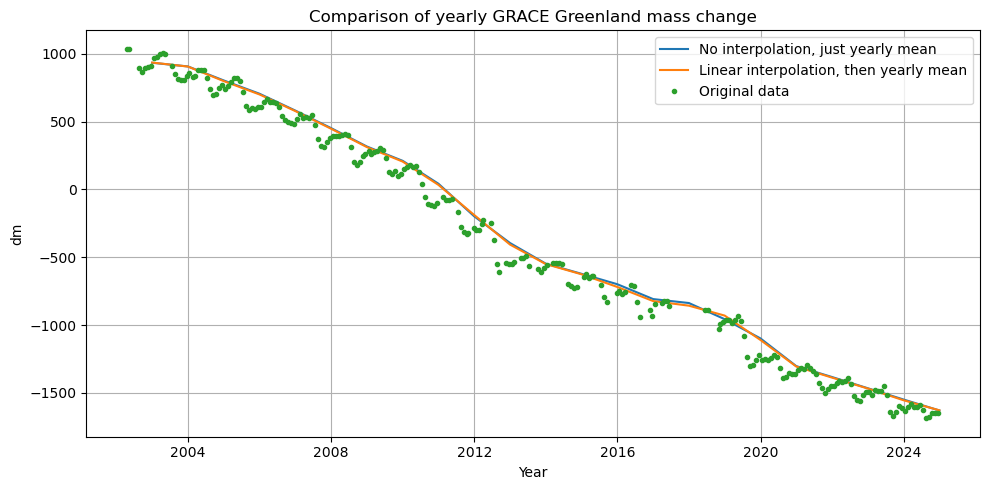

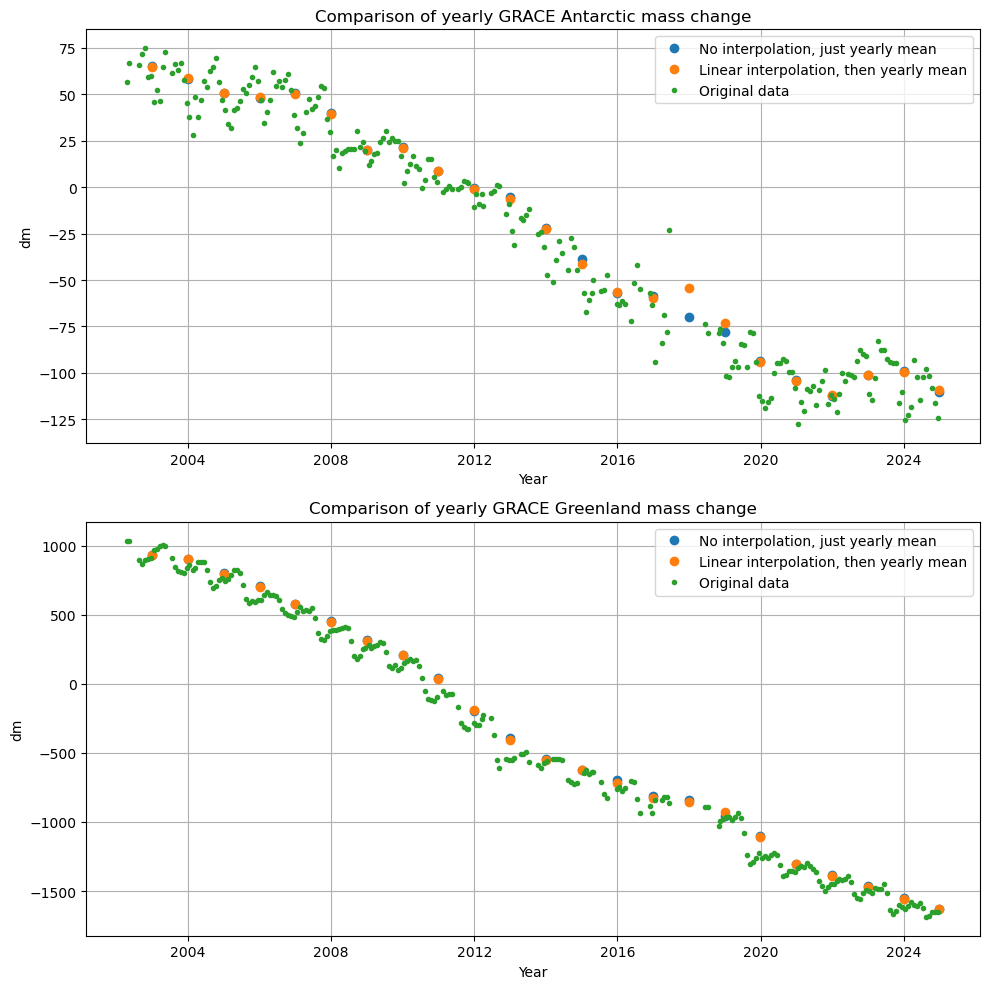

In [5]:


# ---- A. No interpolation ----
ant_y_no = ky.yearlygrace(ant)
gre_y_no = ky.yearlygrace(gre)


# ---- B. Linear interpolation ----
ant_interp = ant.resample(time="M").interpolate("linear")
ant_y_lin = ky.yearlygrace(ant_interp)

gre_interp = gre.resample(time="M").interpolate("linear")
gre_y_lin = ky.yearlygrace(gre_interp)

ts_no   = ant_y_no['dm'].mean(dim=["x","y"])
ts_lin  = ant_y_lin['dm'].mean(dim=["x","y"])
antmean = ant['dm'].mean(dim=["x","y"]) 

ts_nogre   = gre_y_no['dm'].mean(dim=["x","y"])
ts_lingre = gre_y_lin['dm'].mean(dim=["x","y"])
gremean = gre['dm'].mean(dim=["x","y"]) 


plt.figure(figsize=(10,5))

plt.plot(ts_no['time'],  ts_no,  label="No interpolation, just yearly mean")
plt.plot(ts_lin['time'], ts_lin, label="Linear interpolation, then yearly mean")
plt.plot(ant['time'], antmean, label="Original data", linestyle='', marker='.')

plt.title("Comparison of yearly GRACE Antarctic mass change")
plt.xlabel("Year")
plt.ylabel("dm")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))

plt.plot(ts_nogre['time'],  ts_nogre,  label="No interpolation, just yearly mean")
plt.plot(ts_lingre['time'], ts_lingre, label="Linear interpolation, then yearly mean")
plt.plot(gre['time'], gremean, label="Original data", linestyle='', marker='.')

plt.title("Comparison of yearly GRACE Greenland mass change")
plt.xlabel("Year")
plt.ylabel("dm")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=False)

# -----------------------------
# Antarctica (top subplot)
# -----------------------------
ax1.plot(ts_no['time'],  ts_no,  label="No interpolation, just yearly mean", linestyle='', marker='o')
ax1.plot(ts_lin['time'], ts_lin, label="Linear interpolation, then yearly mean", linestyle='', marker='o')
ax1.plot(ant['time'], antmean, linestyle='', marker='.', label="Original data")

ax1.set_title("Comparison of yearly GRACE Antarctic mass change")
ax1.set_xlabel("Year")
ax1.set_ylabel("dm")
ax1.legend()
ax1.grid(True)


# -----------------------------
# Greenland (bottom subplot)
# -----------------------------
ax2.plot(ts_nogre['time'],  ts_nogre,  label="No interpolation, just yearly mean", linestyle='', marker='o')
ax2.plot(ts_lingre['time'], ts_lingre, label="Linear interpolation, then yearly mean", linestyle='', marker='o')
ax2.plot(gre['time'], gremean, linestyle='', marker='.', label="Original data")

ax2.set_title("Comparison of yearly GRACE Greenland mass change")
ax2.set_xlabel("Year")
ax2.set_ylabel("dm")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()



In [6]:
antyear = ant.resample(time="M").interpolate("linear")
display(antyear['time_dec'].values)
display(ant['time_dec'].values)

array([2002.32583636, 2002.41069949, 2002.49284162, 2002.57772183,
       2002.66259672, 2002.74472787, 2002.82959672, 2002.91172787,
       2002.99689194, 2003.08211525, 2003.15880678, 2003.24369672,
       2003.32582157, 2003.41068864, 2003.492825  , 2003.57771129,
       2003.66259672, 2003.74472787, 2003.82959672, 2003.91172787,
       2003.99703864, 2004.08214938, 2004.16154211, 2004.24639672,
       2004.32852787, 2004.41339672, 2004.49552787, 2004.58041129,
       2004.66529672, 2004.74742787, 2004.83229672, 2004.91442787,
       2004.99832903, 2005.08211525, 2005.15880678, 2005.24369672,
       2005.32582787, 2005.41069672, 2005.49282787, 2005.57771129,
       2005.66259672, 2005.74472787, 2005.82959672, 2005.91172787,
       2005.99689194, 2006.08211525, 2006.15880678, 2006.24369672,
       2006.32582787, 2006.41069672, 2006.49282787, 2006.57771129,
       2006.66259672, 2006.74472787, 2006.82959672, 2006.91172787,
       2006.99689194, 2007.0821    , 2007.15879   , 2007.24369

array([2002.293 , 2002.3532, 2002.6229, 2002.7064, 2002.7899, 2002.8734,
       2002.9569, 2003.0424, 2003.1232, 2003.204 , 2003.2875, 2003.3573,
       2003.538 , 2003.6229, 2003.7064, 2003.7899, 2003.8734, 2003.9569,
       2004.0178, 2004.1287, 2004.2067, 2004.2902, 2004.3737, 2004.4572,
       2004.5407, 2004.6256, 2004.7091, 2004.7926, 2004.8761, 2004.9596,
       2005.0424, 2005.1232, 2005.204 , 2005.2875, 2005.371 , 2005.4545,
       2005.538 , 2005.6229, 2005.7064, 2005.7899, 2005.8734, 2005.9569,
       2006.0424, 2006.1232, 2006.204 , 2006.2875, 2006.371 , 2006.4545,
       2006.538 , 2006.6229, 2006.7064, 2006.7899, 2006.8734, 2006.9569,
       2007.0424, 2007.1218, 2007.204 , 2007.2875, 2007.371 , 2007.4545,
       2007.538 , 2007.6229, 2007.7064, 2007.7899, 2007.8734, 2007.9569,
       2008.0424, 2008.1246, 2008.2067, 2008.2902, 2008.3737, 2008.4572,
       2008.5407, 2008.6256, 2008.7091, 2008.7926, 2008.8761, 2008.9596,
       2009.0424, 2009.1232, 2009.204 , 2009.2875, 

In [7]:

# Drop dm, time_dec, and the old time coordinate: this is everything that dempends on time
ant_y = ant.drop_vars(['dm', 'time_dec', 'time'], errors='ignore')

# Resample dm to yearly
dm_y = ant['dm'].resample(time='1Y').mean(keep_attrs=True)

dm_y2 = ant['dm'].groupby('time.year').mean(keep_attrs=True)

dm_y_aligned = dm_y.assign_coords(year=dm_y['time.year']).drop_vars('time')
print(abs(dm_y_aligned - dm_y2).max().item())
print(dm_y_aligned.equals(dm_y2))

dm_count_resample = ant['dm'].resample(time='1Y').count()
dm_count_groupby = ant['dm'].groupby('time.year').count()
print('a', dm_count_resample)
print('b', dm_count_groupby)

# Ensure correct order
dm_y = dm_y.transpose('time', 'y', 'x')
dm_y_g = dm_y_g.transpose('time', 'y', 'x')

# Assign dm back
ant_y = ant_y.assign({'dm': dm_y})
gre_y = gre_y.assign({'dm': dm_y_g})


# Assign the time coordinate from dm_y (now no conflicts)
ant_y = ant_y.assign_coords(time=dm_y['time'])
gre_y = gre_y.assign_coords(time=dm_y_g['time'])

# Compute decimal year as a NumPy array
time_dec = ant_y["time"].dt.year 
time_dec_g = gre_y["time"].dt.year 


# Add it as a new variable (not just a coordinate)
ant_y["time_dec"] = ("time", time_dec.data)
gre_y["time_dec"] = ("time", time_dec_g.data)

# Add metadata (optional but good practice)
ant_y["time_dec"].attrs = {
    "long_name": "Decimal year",
    "units": "year"
}

gre_y["time_dec"].attrs = {
    "long_name": "Decimal year",
    "units": "year"
}

# plot the two difference figures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

(ant['dm'].isel(time=-1)-ant['dm'].isel(time=0)).plot(ax=ax1, cmap='RdBu_r')
ax1.set_title('Change in ice mas between 2002 and 2024 original')

(ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)).plot(ax=ax2, cmap='RdBu_r')
ax2.set_title('Change in ice mas between 2002 and 2024 yearly')
plt.tight_layout()
plt.show()


13072.07380952381
False
a <xarray.DataArray 'dm' (time: 23, y: 97, x: 117)> Size: 2MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 

NameError: name 'dm_y_g' is not defined

In [ ]:
# test resample vs groupby with simple dataset: 



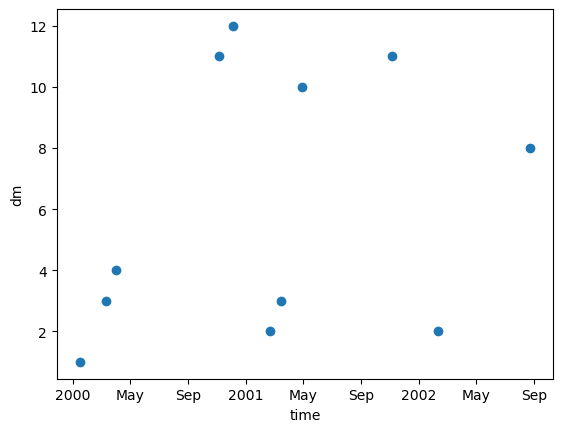

<xarray.DataArray 'dm' (year: 3)> Size: 24B
array([6.2, 6.5, 5. ])
Coordinates:
  * year     (year) int64 24B 2000 2001 2002

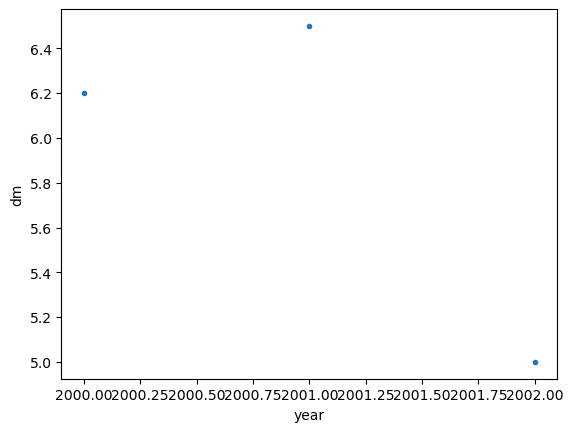

<xarray.DataArray 'dm' (time: 3)> Size: 24B
array([6.2, 6.5, 5. ])
Coordinates:
  * time     (time) datetime64[ns] 24B 2000-12-31 2001-12-31 2002-12-31

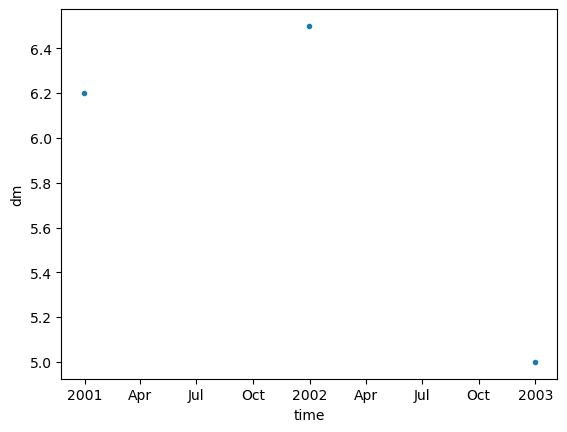

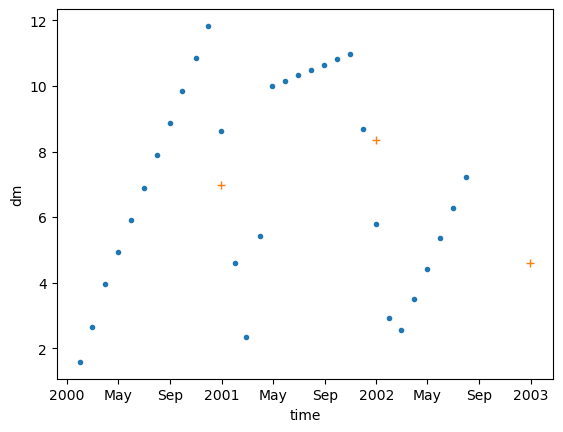

<xarray.DataArray 'dm' (time: 3)> Size: 24B
array([6.98555708, 8.35599623, 4.6121397 ])
Coordinates:
  * time     (time) datetime64[ns] 24B 2000-12-31 2001-12-31 2002-12-31

<xarray.DataArray 'dm' (year: 3)> Size: 24B
array([6.98555708, 8.35599623, 4.6121397 ])
Coordinates:
  * year     (year) int64 24B 2000 2001 2002

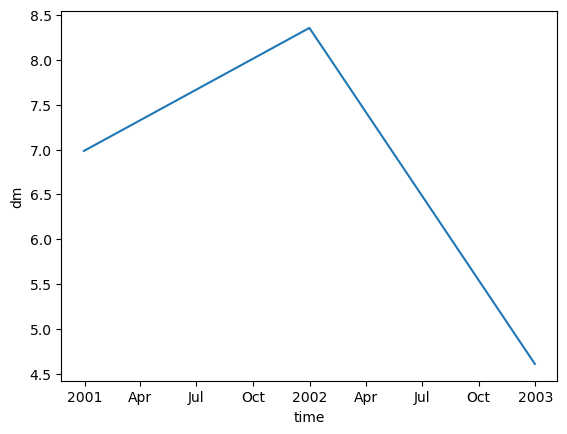

In [8]:
# Create a time series with multiple measurements per year
time = pd.to_datetime([
    "2000-01-15", "2000-03-10", "2000-04-01", "2000-11-05", "2000-12-05",
    "2001-02-20", "2001-03-15", "2001-4-30", "2001-11-05",
    "2002-02-10", "2002-08-25"
])

# Some example measurements
data = [1.0, 3.0, 4.0, 11.0, 12.0, 2.0, 3.0, 10.0, 11.0,  2.0, 8.0]

# Create the DataArray
da = xr.DataArray(
    data,
    coords={"time": time},
    dims=["time"],
    name="dm"
)

#display(da)

da.plot(linestyle='', marker='o')
plt.show()
groupby = da.groupby('time.year').mean()
display(groupby)

groupby.plot(linestyle='', marker='.',label='groupby.mean')
plt.show()

resample = da.resample(time='1Y')

resamplemean = da.resample(time='1Y').mean()
display(resamplemean)

resamplemean.plot(linestyle='', marker='.', label='resample.mean')
plt.show()



interp = da.resample(time="M").interpolate("linear")
interp.plot(linestyle='', marker='.')

interp.resample(time='1Y').mean().plot(linestyle='', marker= '+')
#interp.groupby('time.year').mean().plot(linestyle='', marker= '+')


plt.show()


# Now resample to yearly mean
yearly_mean = interp.resample(time='1Y').mean()
display(yearly_mean)

# Groupby year also works
yearly_group = interp.groupby('time.year').mean()
display(yearly_group)


yearly_mean.plot()



In [9]:
interp = da.resample(time="M").interpolate("linear")

print(interp.groupby("time.year").mean())


# Now resample to yearly mean
yearly_mean = interp.resample(time='1Y').mean()
display(yearly_mean)

# Groupby year also works
yearly_group = interp.groupby('time.year').mean()
display(yearly_group)


<xarray.DataArray 'dm' (year: 3)> Size: 24B
array([6.98555708, 8.35599623, 4.6121397 ])
Coordinates:
  * year     (year) int64 24B 2000 2001 2002


<xarray.DataArray 'dm' (time: 3)> Size: 24B
array([6.98555708, 8.35599623, 4.6121397 ])
Coordinates:
  * time     (time) datetime64[ns] 24B 2000-12-31 2001-12-31 2002-12-31

<xarray.DataArray 'dm' (year: 3)> Size: 24B
array([6.98555708, 8.35599623, 4.6121397 ])
Coordinates:
  * year     (year) int64 24B 2000 2001 2002